# CUB 200 Data Exploration

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = Path.cwd().parent.resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loading import load_cub_preview_images

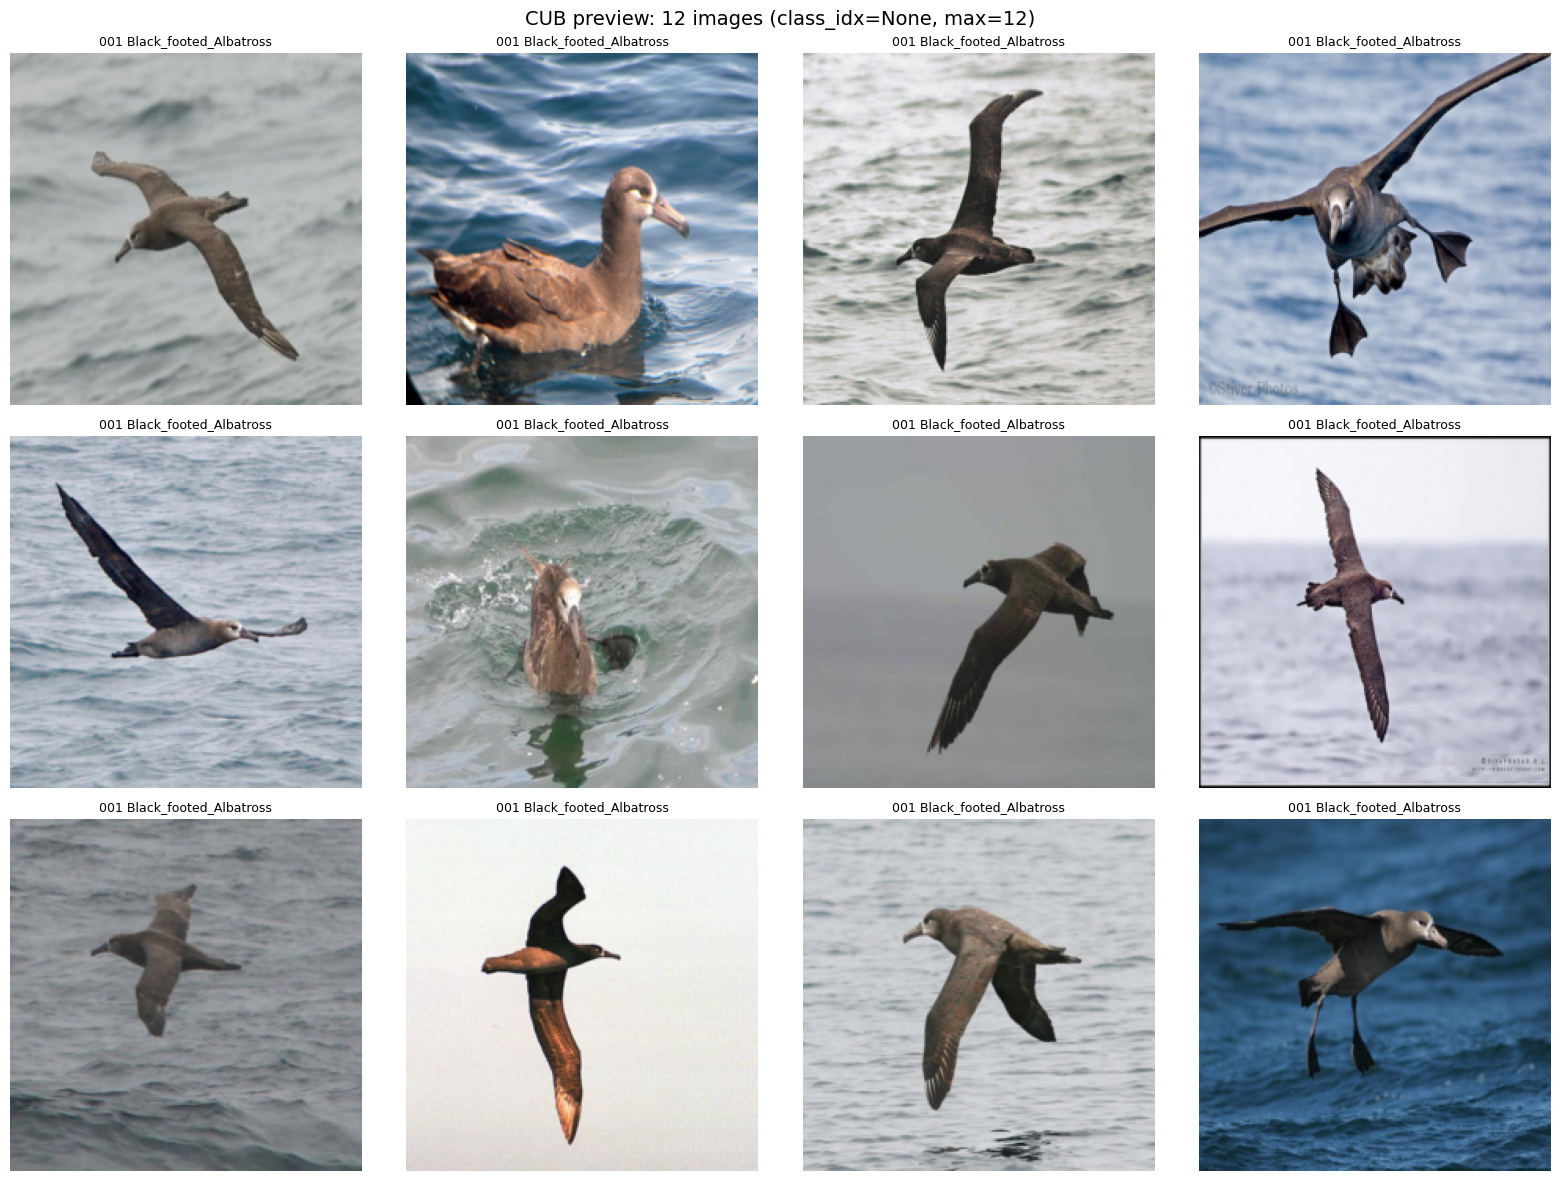

In [9]:
CLASS_IDX = None      
MAX_IMAGES = 12      
COLS = 4              # Num of columns in the image grid

images, labels = load_cub_preview_images(
    class_idx=CLASS_IDX,
    max_images=MAX_IMAGES,
    image_size=(224, 224),
)


rows = (len(images) + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(4 * COLS, 4 * rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, ax in enumerate(axes):
    ax.axis("off")
    if idx >= len(images):
        continue

    img = images[idx].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(labels[idx].replace(".", " "), fontsize=9)

fig.suptitle(
    f"CUB preview: {len(images)} images (class_idx={CLASS_IDX}, max={MAX_IMAGES})",
    fontsize=14,
)
fig.tight_layout()
plt.show()